In [1]:
# CELDA 1: Importar Librerías
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from google.colab import drive

# Conectar Drive
drive.mount('/content/drive')
print("✅ Herramientas de Inteligencia Artificial cargadas.")

Mounted at /content/drive
✅ Herramientas de Inteligencia Artificial cargadas.


In [2]:
# CELDA 2: Cargadores de Datos
ruta_dataset_final = '/content/drive/MyDrive/PPP/Dataset/Dataset_Final/'

TAMAÑO_LOTE = 32
TAMAÑO_IMAGEN = (224, 224)

print("Cargando datos para Entrenamiento (80%)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_dataset_final,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=TAMAÑO_IMAGEN,
    batch_size=TAMAÑO_LOTE,
    color_mode='rgb' # Keras convierte tus grises a 3 canales automáticamente
)

print("\nCargando datos para Exámenes de Validación (20%)...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    ruta_dataset_final,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=TAMAÑO_IMAGEN,
    batch_size=TAMAÑO_LOTE,
    color_mode='rgb'
)

# Optimización para que la lectura de datos sea ultrarrápida en memoria
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n✅ Datos listos y optimizados para el modelo.")

Cargando datos para Entrenamiento (80%)...
Found 2888 files belonging to 2 classes.
Using 2311 files for training.

Cargando datos para Exámenes de Validación (20%)...
Found 2888 files belonging to 2 classes.
Using 577 files for validation.

✅ Datos listos y optimizados para el modelo.


In [3]:
# CELDA 3: Creación del Modelo de Visión
def construir_modelo():
    # 1. Base Pre-entrenada (MobileNetV2)
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False # Congelamos su conocimiento previo
    
    # 2. Nuestra "Cabeza" de Inspección
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x) # Previene que la IA memorice y la obliga a razonar
    
    # 3. Decisión Final: 0 (Buena) o 1 (Mala)
    salida = Dense(1, activation='sigmoid')(x)
    
    modelo = Model(inputs=base_model.input, outputs=salida)
    
    # Compilamos: Le decimos cómo aprender de sus errores
    modelo.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
    return modelo

modelo_inspector = construir_modelo()
print("✅ Arquitectura construida. Resumen del modelo:")
modelo_inspector.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Arquitectura construida. Resumen del modelo:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
# CELDA 3: Creación del Modelo de Visión
def construir_modelo():
    # 1. Base Pre-entrenada (MobileNetV2)
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False # Congelamos su conocimiento previo
    
    # 2. Nuestra "Cabeza" de Inspección
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x) # Previene que la IA memorice y la obliga a razonar
    
    # 3. Decisión Final: 0 (Buena) o 1 (Mala)
    salida = Dense(1, activation='sigmoid')(x)
    
    modelo = Model(inputs=base_model.input, outputs=salida)
    
    # Compilamos: Le decimos cómo aprender de sus errores
    modelo.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
    return modelo

modelo_inspector = construir_modelo()
print("✅ Arquitectura construida. Resumen del modelo:")
modelo_inspector.summary()

✅ Arquitectura construida. Resumen del modelo:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# CELDA 4: Entrenamiento de la Inteligencia Artificial
EPOCAS = 15

# Parada inteligente si el modelo ya aprendió lo suficiente
parada_temprana = EarlyStopping(
    monitor='val_accuracy', 
    patience=3, # Si en 3 rondas no mejora, se detiene
    restore_best_weights=True # Se queda con la mejor versión
)

print("🚀 Iniciando el entrenamiento...")
historial = modelo_inspector.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCAS,
    callbacks=[parada_temprana]
)
print("\n🎉 ¡Entrenamiento Finalizado!")

🚀 Iniciando el entrenamiento...
Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 929s 3s/step - accuracy: 0.9204 - loss: 0.1982 - val_accuracy: 0.9861 - val_loss: 0.0549
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9905 - loss: 0.0352 - val_accuracy: 0.9948 - val_loss: 0.0324
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9957 - loss: 0.0208 - val_accuracy: 0.9896 - val_loss: 0.0279
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9957 - loss: 0.0168 - val_accuracy: 0.9948 - val_loss: 0.0204
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9983 - loss: 0.0092 - val_accuracy: 0.9965 - val_loss: 0.0173
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9991 - loss: 0.0068 - val_accuracy: 0.9965 - val_loss: 0.0164
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9991 - loss: 0.0055 - val_accuracy: 0.9965 - val_loss: 0.0176
Epoch 8/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9996 - loss: 0

In [6]:
# CELDA 5: GUARDAR EL MODELO ENTRENADO
# ⚠️ Asegúrate de ejecutar esta celda justo en cuanto termine el entrenamiento (Celda 4)

# 1. Definimos la ruta exacta en tu Google Drive
ruta_guardado = '/content/drive/MyDrive/PPP/modelo_inspector_botellas.keras'

# 2. La línea mágica que empaqueta todo el conocimiento
modelo_inspector.save(ruta_guardado)

print(f"💾 ¡Éxito! El cerebro de la IA ha sido guardado permanentemente en: {ruta_guardado}")


💾 ¡Éxito! El cerebro de la IA ha sido guardado permanentemente en: /content/drive/MyDrive/PPP/modelo_inspector_botellas.keras


📊 TABLA DE RENDIMIENTO DEL MODELO:



,Error Entrenamiento (loss),Precisión Entrenamiento (acc),Error Validación (val_loss),Precisión Validación (val_acc)
Época,,,,
1,0.920381,0.198215,0.986135,0.054903
2,0.990480,0.035166,0.994801,0.032405
3,0.995673,0.020847,0.989601,0.027902
4,0.995673,0.016796,0.994801,0.020404
5,0.998269,0.009182,0.996534,0.017339
6,0.999135,0.006825,0.996534,0.016415
7,0.999135,0.005490,0.996534,0.017609
8,0.999567,0.004117,0.996534,0.017679


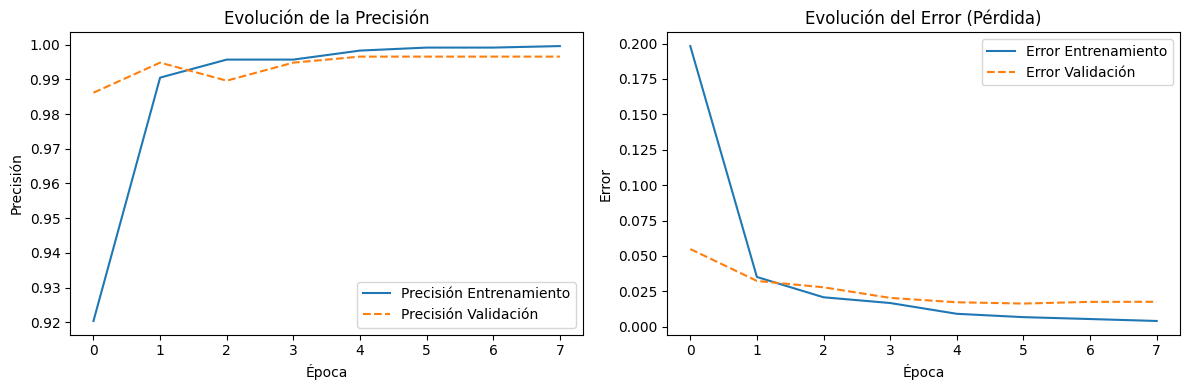

In [7]:
# CELDA 5: Tabla de Resultados, Gráficos y Guardado
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. MOSTRAR RESULTADOS EN FORMATO TABLA
# ==========================================
# Convertimos el historial de la IA en una tabla estructurada (DataFrame)
tabla_resultados = pd.DataFrame(historial.history)
tabla_resultados.index += 1 # Para que la cuenta de épocas empiece en 1 y no en 0
tabla_resultados.index.name = 'Época'

# Renombramos las columnas para que estén en español y se vean profesionales
tabla_resultados.columns = ['Error Entrenamiento (loss)', 'Precisión Entrenamiento (acc)', 
                            'Error Validación (val_loss)', 'Precisión Validación (val_acc)']

print("📊 TABLA DE RENDIMIENTO DEL MODELO:\n")
display(tabla_resultados) # 'display' muestra tablas muy estéticas en los Notebooks

# ==========================================
# 2. GRAFICAR EL APRENDIZAJE
# ==========================================
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Precisión Entrenamiento')
plt.plot(val_acc, label='Precisión Validación', linestyle='--')
plt.title('Evolución de la Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Error Entrenamiento')
plt.plot(val_loss, label='Error Validación', linestyle='--')
plt.title('Evolución del Error (Pérdida)')
plt.xlabel('Época')
plt.ylabel('Error')
plt.legend()
plt.tight_layout()
plt.show()

📝 Iniciando el Examen Global...


👁️ Tomando 5 botellas al azar para una prueba visual...
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


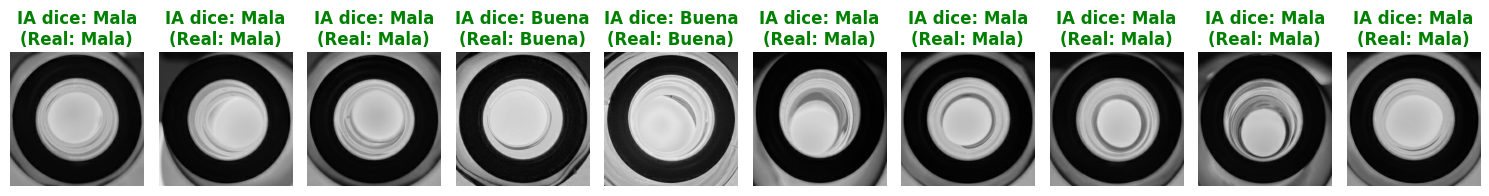

In [8]:
# CELDA 6: EL EXAMEN FINAL (Evaluación del Modelo)
import numpy as np
import matplotlib.pyplot as plt

print("📝 Iniciando el Examen Global...\n")


# 2. EL EXAMEN VISUAL (Prueba en vivo)
print("\n👁️ Tomando 5 botellas al azar para una prueba visual...")

# Sacamos un lote (batch) de 32 imágenes de las que nunca ha visto
for imagenes, etiquetas_reales in val_ds.take(1):
    
    # Le pedimos a la IA que haga su predicción
    predicciones = modelo_inspector.predict(imagenes)
    
    plt.figure(figsize=(15, 5))
    
    # Vamos a mostrar solo las primeras 5 botellas de ese lote
    for i in range(10):
        plt.subplot(1, 10, i+1)
        
        # Convertimos la imagen para poder verla bien en pantalla
        img_mostrar = imagenes[i].numpy().astype("uint8")
        plt.imshow(img_mostrar)
        
        # La IA arroja una probabilidad (0.0 a 1.0)
        # Como "Botellas_Buenas" es 0 y "Botellas_Malas" es 1 (orden alfabético)
        probabilidad = predicciones[i][0]
        clase_predicha = 1 if probabilidad > 0.5 else 0
        
        # Obtenemos la respuesta real (la carpeta de donde vino)
        clase_real = etiquetas_reales[i].numpy()
        
        texto_ia = 'Mala' if clase_predicha == 1 else 'Buena'
        texto_real = 'Mala' if clase_real == 1 else 'Buena'
        
        # Si acertó, texto verde. Si falló, texto rojo.
        color = 'green' if clase_predicha == clase_real else 'red'
        
        plt.title(f"IA dice: {texto_ia}\n(Real: {texto_real})", color=color, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    break # Solo queremos ver un lote

🔍 Analizando a fondo el examen de validación...



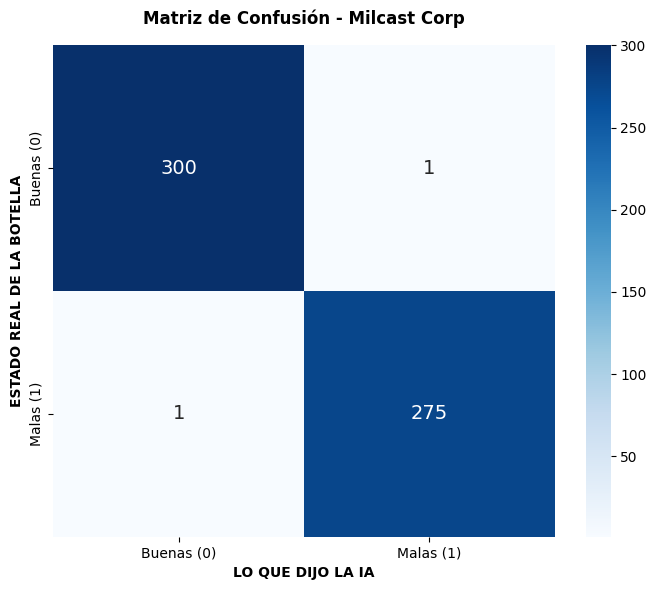


📋 REPORTE DETALLADO DE RENDIMIENTO:

              precision    recall  f1-score   support

      Buenas       1.00      1.00      1.00       301
       Malas       1.00      1.00      1.00       276

    accuracy                           1.00       577
   macro avg       1.00      1.00      1.00       577
weighted avg       1.00      1.00      1.00       577



In [9]:
# CELDA 7: MATRIZ DE CONFUSIÓN (Auditoría del Error)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("🔍 Analizando a fondo el examen de validación...\n")

etiquetas_reales = []
predicciones_ia = []

# Recorremos todas las imágenes del examen en silencio
for imagenes, etiquetas in val_ds:
    # La IA hace su predicción
    preds = modelo_inspector.predict(imagenes, verbose=0)
    
    # Guardamos la respuesta correcta (la que tú definiste al separar en carpetas)
    etiquetas_reales.extend(etiquetas.numpy())
    
    # Convertimos el porcentaje de la IA en una decisión firme (0 o 1)
    preds_binarias = [1 if p > 0.5 else 0 for p in preds.flatten()]
    predicciones_ia.extend(preds_binarias)

# Calculamos la matriz matemática
matriz = confusion_matrix(etiquetas_reales, predicciones_ia)

# --- DIBUJAR LA MATRIZ ---
plt.figure(figsize=(7, 6))
nombres_clases = ['Buenas (0)', 'Malas (1)'] 

# Creamos un mapa de calor muy visual
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases,
            annot_kws={"size": 14}) # Números más grandes

plt.title('Matriz de Confusión - Milcast Corp', fontweight='bold', pad=15)
plt.ylabel('ESTADO REAL DE LA BOTELLA', fontweight='bold')
plt.xlabel('LO QUE DIJO LA IA', fontweight='bold')
plt.tight_layout()
plt.show()

# --- REPORTE DETALLADO ---
print("\n📋 REPORTE DETALLADO DE RENDIMIENTO:\n")
print(classification_report(etiquetas_reales, predicciones_ia, target_names=['Buenas', 'Malas']))